## Notebook for satellite-based simulations

This notebook contains postprocessing analysis of simulations initialized on Sargassum satellite detections and includes:
- Sensitivity analysis of growth model to different k_N (nitrate half saturation) values
- Comparison of simulation and satellite data after 1 month
- Growth/transport distribution results

In [1]:
#NOTEBOOK FOR ANALYSIS OF SARGASSUM SIMULATIONS FOR 12 START TIMES

import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import scipy

import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta
import calculate_distance as c_d
import calculate_2DHistogram_method01 as c_H
import grid_initialization as gi
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from matplotlib import colormaps as mcolormaps

In [2]:
#Opening datasets of all Lagrangian simulations (12 months)
DSL1 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SIM_part3/SIM8_LG_LA_2024_01.zarr").dropna(dim='obs', how='all')

DSL7 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SIM_part3/SIM8_LG_LA_2024_07.zarr").dropna(dim='obs', how='all')


#Opening dataset of Lagrangian simulation based on satellite data release locations

DSS1 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM2_LA_2024_07_01.zarr").dropna(dim='obs', how='all')

DSS2de = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM3_LA_2024_07_01.zarr").dropna(dim='obs', how='all')

DSSN2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM4_LA_2024_07_01_kN=0.001.zarr").dropna(dim='obs', how='all')

DSSN3 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM5_LA_2024_07_01_kN=0.01.zarr").dropna(dim='obs', how='all')

DSS1E = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM1_EU_2024_07_01.zarr").dropna(dim='obs', how='all')



#Starttime definitions
starttimejul = datetime(2024,7,1)

DSL1 = DSSN2

#Definition of time array
time_in_hours = ((DSL1['time']-DSL1['time'][:,0]).astype("timedelta64[h]"))

time_in_days = ((DSL1['time'] - DSL1['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

print('Size of DS1 file:' , DSL1.sizes, 'and time file: ', time_in_days.sizes)


Size of DS1 file: Frozen({'trajectory': 103642, 'obs': 372}) and time file:  Frozen({'trajectory': 103642, 'obs': 372})


In [3]:
DSSs = [DSS1]
DSNs = [DSSN2]
DSSEs = [DSS1E]

both=[DSS1, DSS1E]
kN = [DSS1, DSSN2]

In [5]:
DSS1.sizes

Frozen({'trajectory': 103642, 'obs': 372})

[[1.0000311 1.0004054 1.0007821 ... 1.2353196 1.235648  1.2359746]
 [1.0000314 1.0004082 1.0007868 ... 1.2332202 1.233572  1.2339256]
 [1.0000315 1.0004103 1.000791  ... 1.2322149 1.2325718 1.2329317]
 ...
 [1.0002203 1.0028744 1.0055457 ... 2.6713488 2.6809673 2.6906152]
 [1.00022   1.0028709 1.0055401 ... 2.6760046 2.6856384 2.695302 ]
 [1.0002197 1.0028669 1.005535  ... 2.6809142 2.6905632 2.700241 ]]
0.585163
3.4360268
1.2051617
len: (103642,)


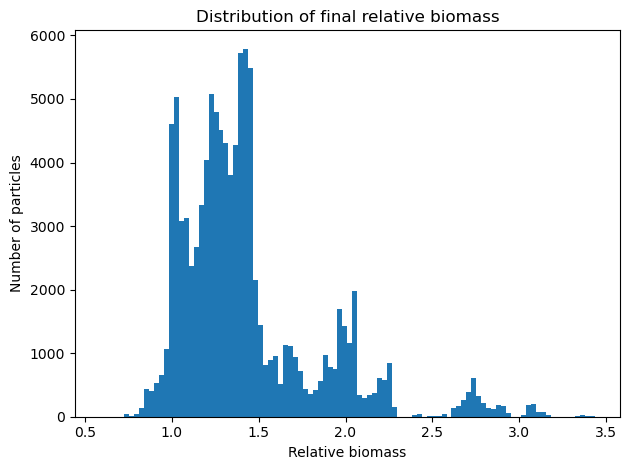

In [4]:
n_bins = 100

print(DSSN2['biomass_SF3'].values)
print(DSSN2['biomass_SF3'].values.min())
print(DSSN2['biomass_SF3'].values.max())
print(DSSN2['biomass_SF3'].values.mean())
final_biomass =    DSSN2.biomass_SF3[:,-1].values
print('len:', np.shape(final_biomass))

# Generate two normal distributions
#dist1 = rng.standard_normal(N_points)

fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)
ax.hist(final_biomass, bins=n_bins
        #, range = (0,0.4), log = True
)
plt.title('Distribution of final relative biomass')
plt.xlabel('Relative biomass')
plt.ylabel('Number of particles')
# plt.xlim(-0.01,0.32)
plt.show()

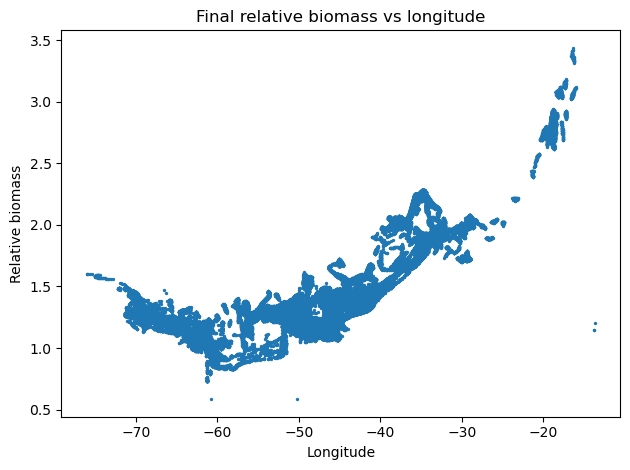

In [11]:
fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)
ax.scatter(DSSN2['lon'][:,-1].values, final_biomass , s = 2)
plt.title('Final relative biomass vs longitude')
plt.xlabel('Longitude')
plt.ylabel('Relative biomass')
# plt.xlim(-0.01,0.32)
plt.show()

[[0.00134294 0.00134923 0.00135532 ... 0.00108113 0.00107371 0.0010661 ]
 [0.00134307 0.00134937 0.0013556  ... 0.00109177 0.00108589 0.00107979]
 [0.00134319 0.00134954 0.0013558  ... 0.00109456 0.0010906  0.00108647]
 ...
 [0.01354417 0.01430552 0.01491118 ... 0.03489195 0.0338407  0.0329244 ]
 [0.0132558  0.01399234 0.01458614 ... 0.03464862 0.03363248 0.0327375 ]
 [0.01296743 0.01367121 0.01441603 ... 0.03401691 0.03300971 0.03212325]]
0.0
11.205444
0.012838406
len: (1, 103642)


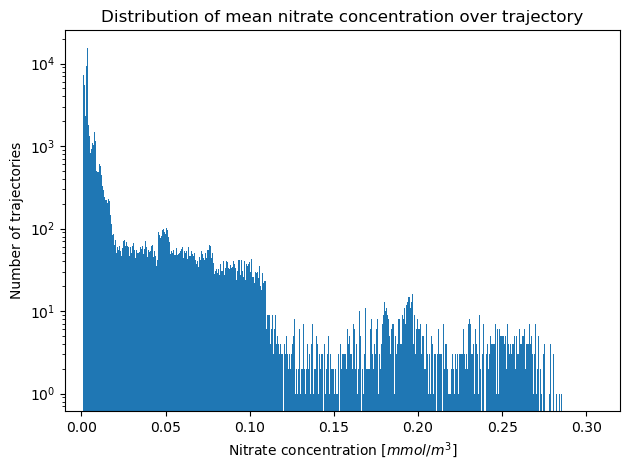

In [9]:

n_bins = 1000

print(DSSN2['nitrogen'].values)
print(DSSN2['nitrogen'].values.min())
print(DSSN2['nitrogen'].values.max())
print(DSSN2['nitrogen'].values.mean())
no3_timemean =    [E['nitrogen'].mean(dim='obs')     for E in DSNs] 
print('len:', np.shape(no3_timemean))

# Generate two normal distributions
#dist1 = rng.standard_normal(N_points)

fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True)
ax.hist(no3_timemean, bins=n_bins, range = (0,0.4), log = True)
plt.title('Distribution of mean nitrate concentration over trajectory')
plt.xlabel('Nitrate concentration [$mmol / m^3$]')
plt.ylabel('Number of trajectories')
plt.xlim(-0.01,0.32)
plt.show()



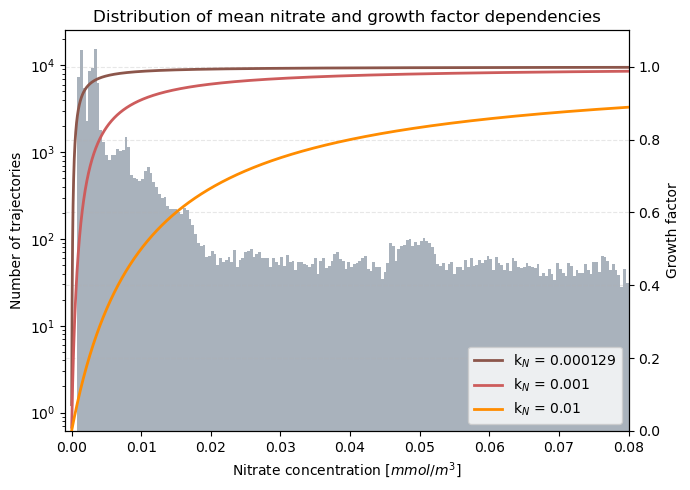

In [7]:
N = np.arange(0.00001,0.1,0.00001)
S = np.arange(20,40,0.05)

#Nitrogen half saturation constant
k_N  = 0.000129 #mmol/m3
k_N2  = 0.001 #mmol/m3
k_N3 = 0.01 #mmol/m3

#Growth factor curves
growth_factor_N = N / (N + k_N )
growth_factor_N2 = N / (N + k_N2)
growth_factor_N3 = N / (N + k_N3)

fig, ax1 = plt.subplots(figsize=(7,5))

#Primary axis: histogram
ax1.hist(no3_timemean, bins=n_bins, range=(0, 0.4), log=True, color='slategray', alpha=0.6)
ax1.set_xlabel('Nitrate concentration [$mmol / m^3$]')
ax1.set_ylabel('Number of trajectories')
ax1.set_title('Distribution of mean nitrate and growth factor dependencies')

#Secondary axis
ax2 = ax1.twinx()

ax2.plot(N, growth_factor_N,  label=f'k$_N$ = {k_N}', color='tab:brown', linewidth = 2)
ax2.plot(N, growth_factor_N2, label=f'k$_N$ = {k_N2}', color='indianred', linewidth = 2)
ax2.plot(N, growth_factor_N3, label=f'k$_N$ = {k_N3}', color='darkorange', linewidth = 2)

ax2.set_ylabel('Growth factor')
ax2.set_ylim(0, 1.1)      
ax2.set_xlim(-0.001, 0.08)
ax2.grid(alpha=0.3, linestyle='--')

ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

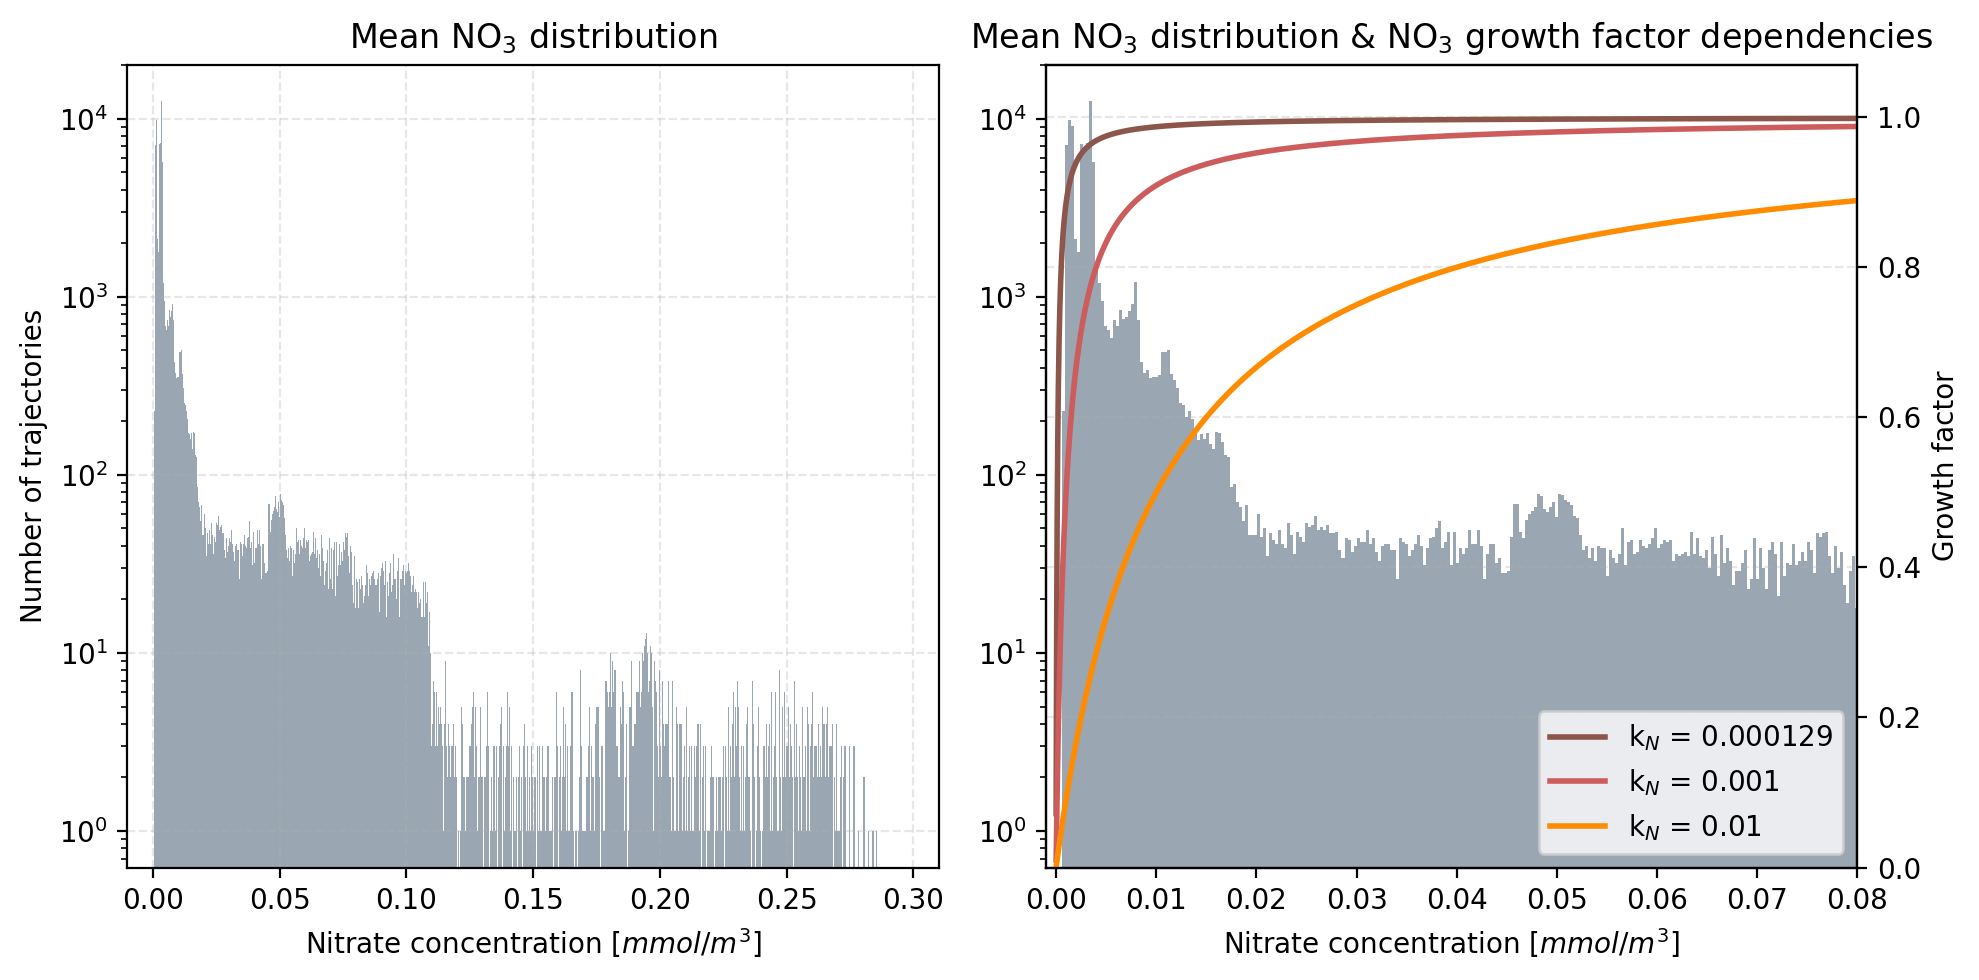

In [8]:
fig_growthcurves, ((ax, ax1)) = plt.subplots(1, 2,figsize=(10,5),dpi=200)

ax.hist(no3_timemean, bins=n_bins, range=(0, 0.3), log=True, color='slategray', alpha=0.7)
ax.set_xlabel('Nitrate concentration [$mmol / m^3$]')
ax.set_ylabel('Number of trajectories')
ax.set_title(f'Mean NO$_3$ distribution')
ax.set_xlim(-0.01, 0.31)
#ax.set_xlim(-0.001, 0.08)
ax.grid(alpha=0.3, linestyle='--')

#Primary axis: histogram
ax1.hist(no3_timemean, bins=n_bins, range=(0, 0.3), log=True, color='slategray', alpha=0.7)
ax1.set_xlabel('Nitrate concentration [$mmol / m^3$]')
ax1.set_title(f'Mean NO$_3$ distribution & NO$_3$ growth factor dependencies')

#Secondary axis
ax2 = ax1.twinx()
ax2.plot(N, growth_factor_N,  label=f'k$_N$ = {k_N}', color='tab:brown', linewidth = 2)
ax2.plot(N, growth_factor_N2, label=f'k$_N$ = {k_N2}', color='indianred', linewidth = 2)
ax2.plot(N, growth_factor_N3, label=f'k$_N$ = {k_N3}', color='darkorange', linewidth = 2)

ax2.set_ylabel('Growth factor')
ax2.set_ylim(0, 1.07)      
ax2.set_xlim(-0.001, 0.08)
ax2.grid(alpha=0.3, linestyle='--')

ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [10]:
#August data to check
imgaug1 = "/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"
imgaug2 = "/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"
imgaug3 = '/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.png'

(2, 372)


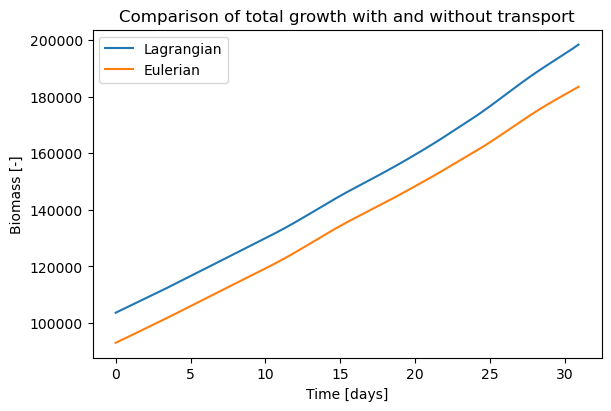

In [11]:

#Calculating the mean over time
weights = [L['biomass_SF3'][:,:].sum(dim='trajectory')   for L in both] 
weights = np.array(weights)
labels = ['Lagrangian', 'Eulerian']

#Definition of time array
time_in_hours = ((DSS1['time']-DSS1['time'][:,0]).astype("timedelta64[h]"))

time_in_days = ((DSS1['time'] - DSS1['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24


print(np.shape(weights))

weightplot = plt.figure(figsize=(6,4), constrained_layout=True)
for i in range(len(weights)):
    plt.plot(time_in_days[0,:], weights[i,:], label = labels[i])

plt.xlabel('Time [days]')
plt.ylabel('Biomass [-]')
plt.title('Comparison of total growth with and without transport')
plt.legend()
plt.show()

In [23]:
aug_lon_C, aug_lat_C, amount_aug_C = gi.sarg_grid_from_sat(imgaug1, 22.0, 0.0, -38.0, -63.0, coarse=True, as_pset=False)
aug_lon_CE, aug_lat_CE, amount_aug_CE = gi.sarg_grid_from_sat(imgaug2, 22.0, 0.0, -11.5, -38.0, coarse=True, as_pset=False)
aug_lon_E, aug_lat_E, amount_aug_E = gi.sarg_grid_from_sat(imgaug3, 23.0, 10.0, -60.0, -75.0, coarse=True, as_pset=False)

Shape of grid: (1210, 1375)
Reshaped grid as particle set: (106575,)
Shape of grid: (1210, 1458)
Reshaped grid as particle set: (22148,)
Shape of grid: (715, 825)
Reshaped grid as particle set: (51953,)


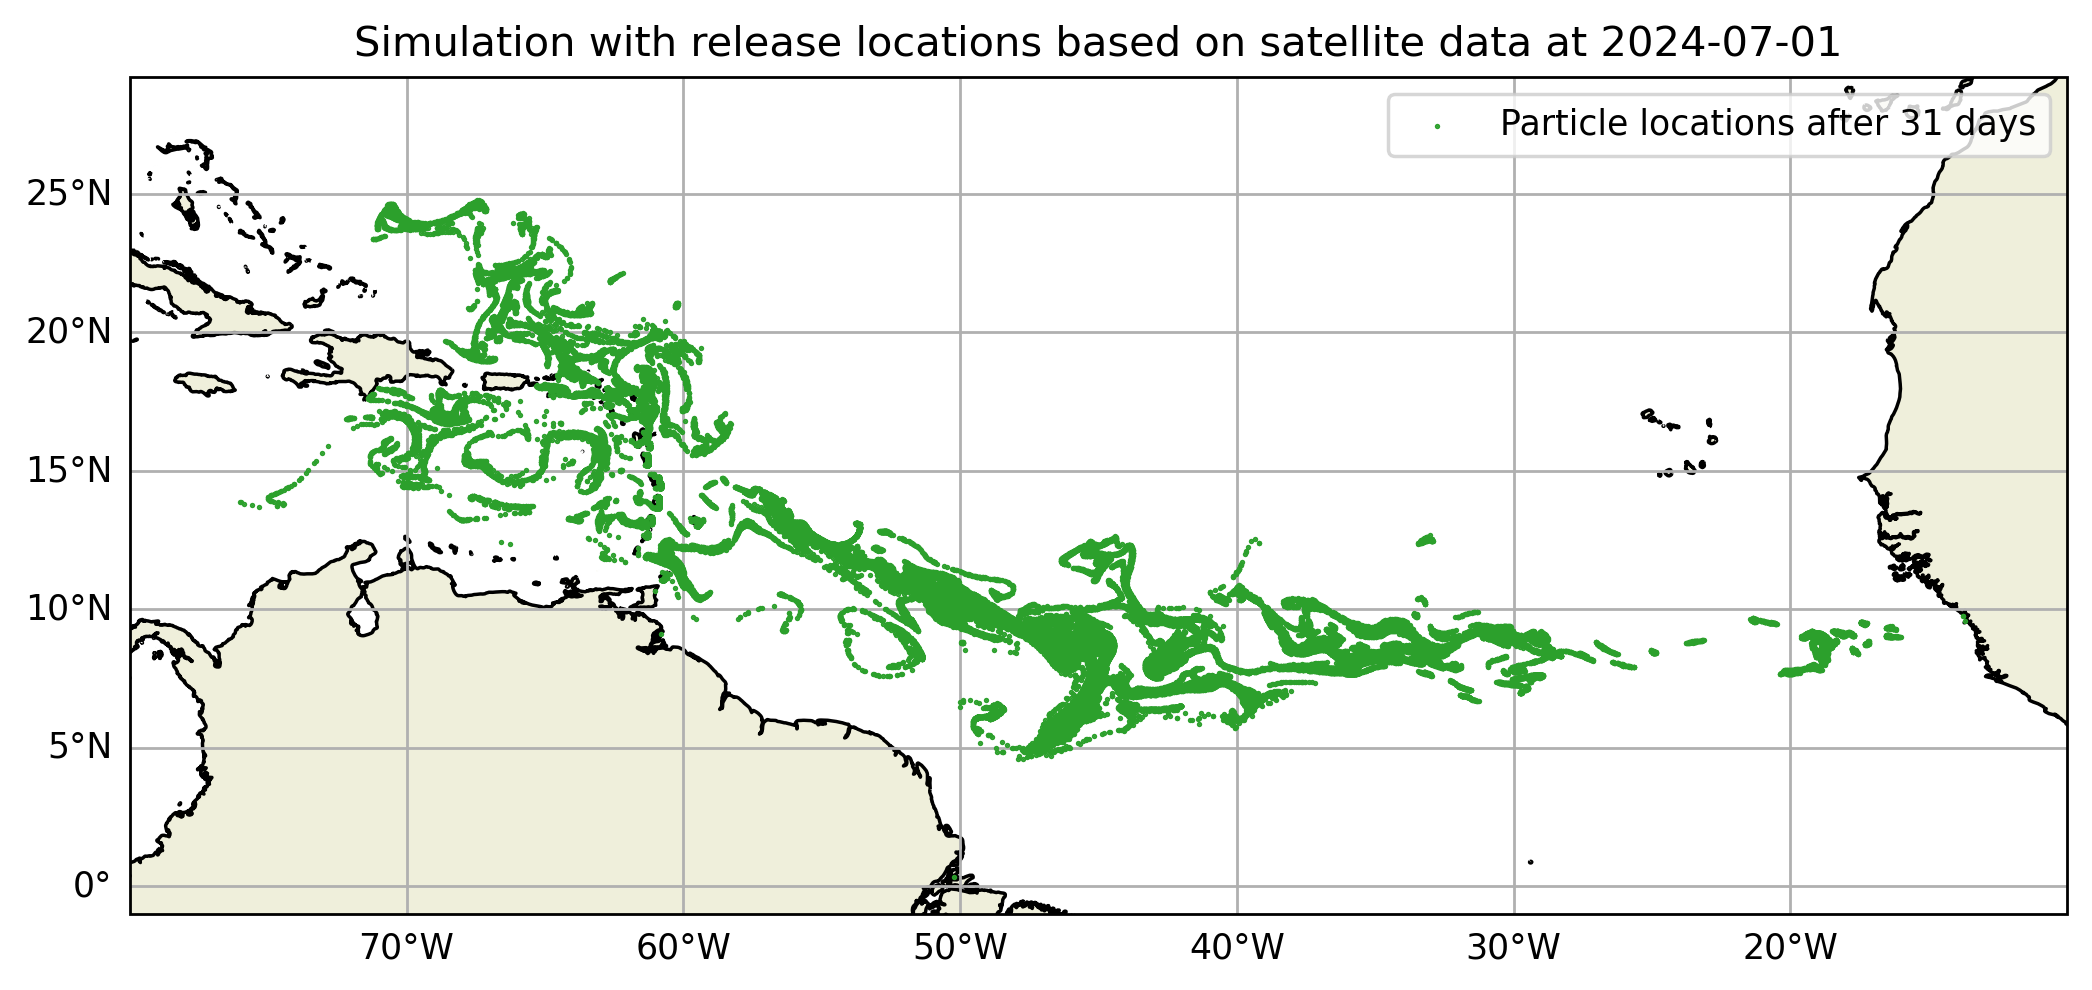

In [ ]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import shapely

#pincar = DSL1.where(hi, drop=False)
#pincar

#Figure for plotting trajectories
fig2 = plt.figure(figsize = (10,6), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())

#End locations scatterplot
#eplot = ax.scatter(DSL1.lon[:,-1], DSL1.lat[:,-1], s = 0.5 ,color='tab:red', label= 'Jan transport') #Transposing lon and lat arrays!
#eplot = ax.scatter(DSS1.lon[:,0], DSS1.lat[:,0], s = 0.5 ,color='violet', label = 'Starting locations') #Transposing lon and lat arrays!


# satplot = ax.scatter(aug_lon_C, aug_lat_C, s = 0.3, c='b', label='Satellite detections at 01-08-2024',zorder=6)
# satplot2 = ax.scatter(aug_lon_CE, aug_lat_CE, s = 0.3, c='b', zorder=6)
# satplot3 = ax.scatter(aug_lon_E, aug_lat_E, s = 0.3, c='b', zorder=6)
eplot = ax.scatter(DSS1.lon[:,-1], DSS1.lat[:,-1], s = 0.3 ,color='tab:green', label = 'Particle locations after 31 days',zorder=7) #Transposing lon and lat arrays!
#eplot = ax.scatter(DSS2de.lon[:,-1], DSS2de.lat[:,-1], s = 0.3 ,color='tab:brown', label = 'Particle locations after 31 days, biomass dependence',zorder=7) #Transposing lon and lat arrays!
#eplot = ax.scatter(DSS1.lon[:,0], DSS1.lat[:,0], s = 0.3 ,color='tab:purple', label = 'Particle locations start',zorder=7) #Transposing lon and lat arrays!

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Simulation with release locations based on satellite data at {starttimejul.date()}')
ax.set_extent([-80,-10,-1,25])
ax.legend()
plt.show()

In [ ]:
import shapely
import xarray as xr
import geopandas as gpd

caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")


def in_polygon_function(ds, poly):
    """Return a boolean DataArray marking points inside the polygon."""
    # Create shapely Point objects for all (lon, lat) pairs
    points = shapely.points(ds.lon, ds.lat)

    # Vectorized containment check (returns a boolean NumPy array)
    mask = shapely.contains(poly, points)

    # Wrap it back into an xarray DataArray with original coordinates
    return xr.DataArray(mask, coords=ds.coords)

hi = in_polygon_function(DSS1, caribbean_poly.geometry.iloc[0])
hi

<xarray.DataArray (trajectory: 103642, obs: 372)> Size: 39MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(103642, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 829kB 0 1 2 3 ... 103638 103639 103640 103641

In [14]:
import shapely
import xarray as xr
import geopandas as gpd

caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")


def in_polygon_function(ds, poly):
    """Return a boolean DataArray marking points inside the polygon."""
    # Create shapely Point objects for all (lon, lat) pairs
    points = shapely.points(ds.lon, ds.lat)

    # Vectorized containment check (returns a boolean NumPy array)
    mask = shapely.contains(poly, points)

    # Wrap it back into an xarray DataArray with original coordinates
    return xr.DataArray(mask, coords=ds.coords)

hi = in_polygon_function(DSS1, caribbean_poly.geometry.iloc[0])


def amount_in_car(input_dataset):
    caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")
    data_in_polygon = in_polygon_function(input_dataset, caribbean_poly.geometry.iloc[0])
    # Count how many are True at obs = 0
    n_true_start = data_in_polygon.isel(obs=0).sum().item()

    # Count how many are True at the last obs
    n_true_end = data_in_polygon.isel(obs=-1).sum().item()

    print(f"True at obs=0, so amount of particles in Car initially: {n_true_start}")
    print(f"True at last obs, so amount of particles in Car after simulation: {n_true_end}")

    total = hi.sizes["trajectory"]
    print(f"Start: {n_true_start/total:.2%}")
    print(f"End:   {n_true_end/total:.2%}")

    return data_in_polygon
#amount_in_car(D)
amount_in_car(DSS2de)

True at obs=0, so amount of particles in Car initially: 3490
True at last obs, so amount of particles in Car after simulation: 18755
Start: 3.37%
End:   18.10%


<xarray.DataArray (trajectory: 103642, obs: 372)> Size: 39MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(103642, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 829kB 0 1 2 3 ... 103638 103639 103640 103641

In [ ]:
# Compute differences between consecutive observations along obs
# We pad with a False at the beginning to preserve shape
prev = hi.shift(obs=1, fill_value=False)

# Rising edge: False → True
first_true_after_false = hi & ~prev

# Falling edge: True → False
first_false_after_true = ~hi & prev

n_true_after_false = first_true_after_false.sum(dim="obs")
n_false_after_true = first_false_after_true.sum(dim="obs")
print("Rising edges:", int(first_true_after_false.sum()))
print("Falling edges:", int(first_false_after_true.sum()))

first_false_after_true

NameError: name 'hi' is not defined

/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:498: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creati

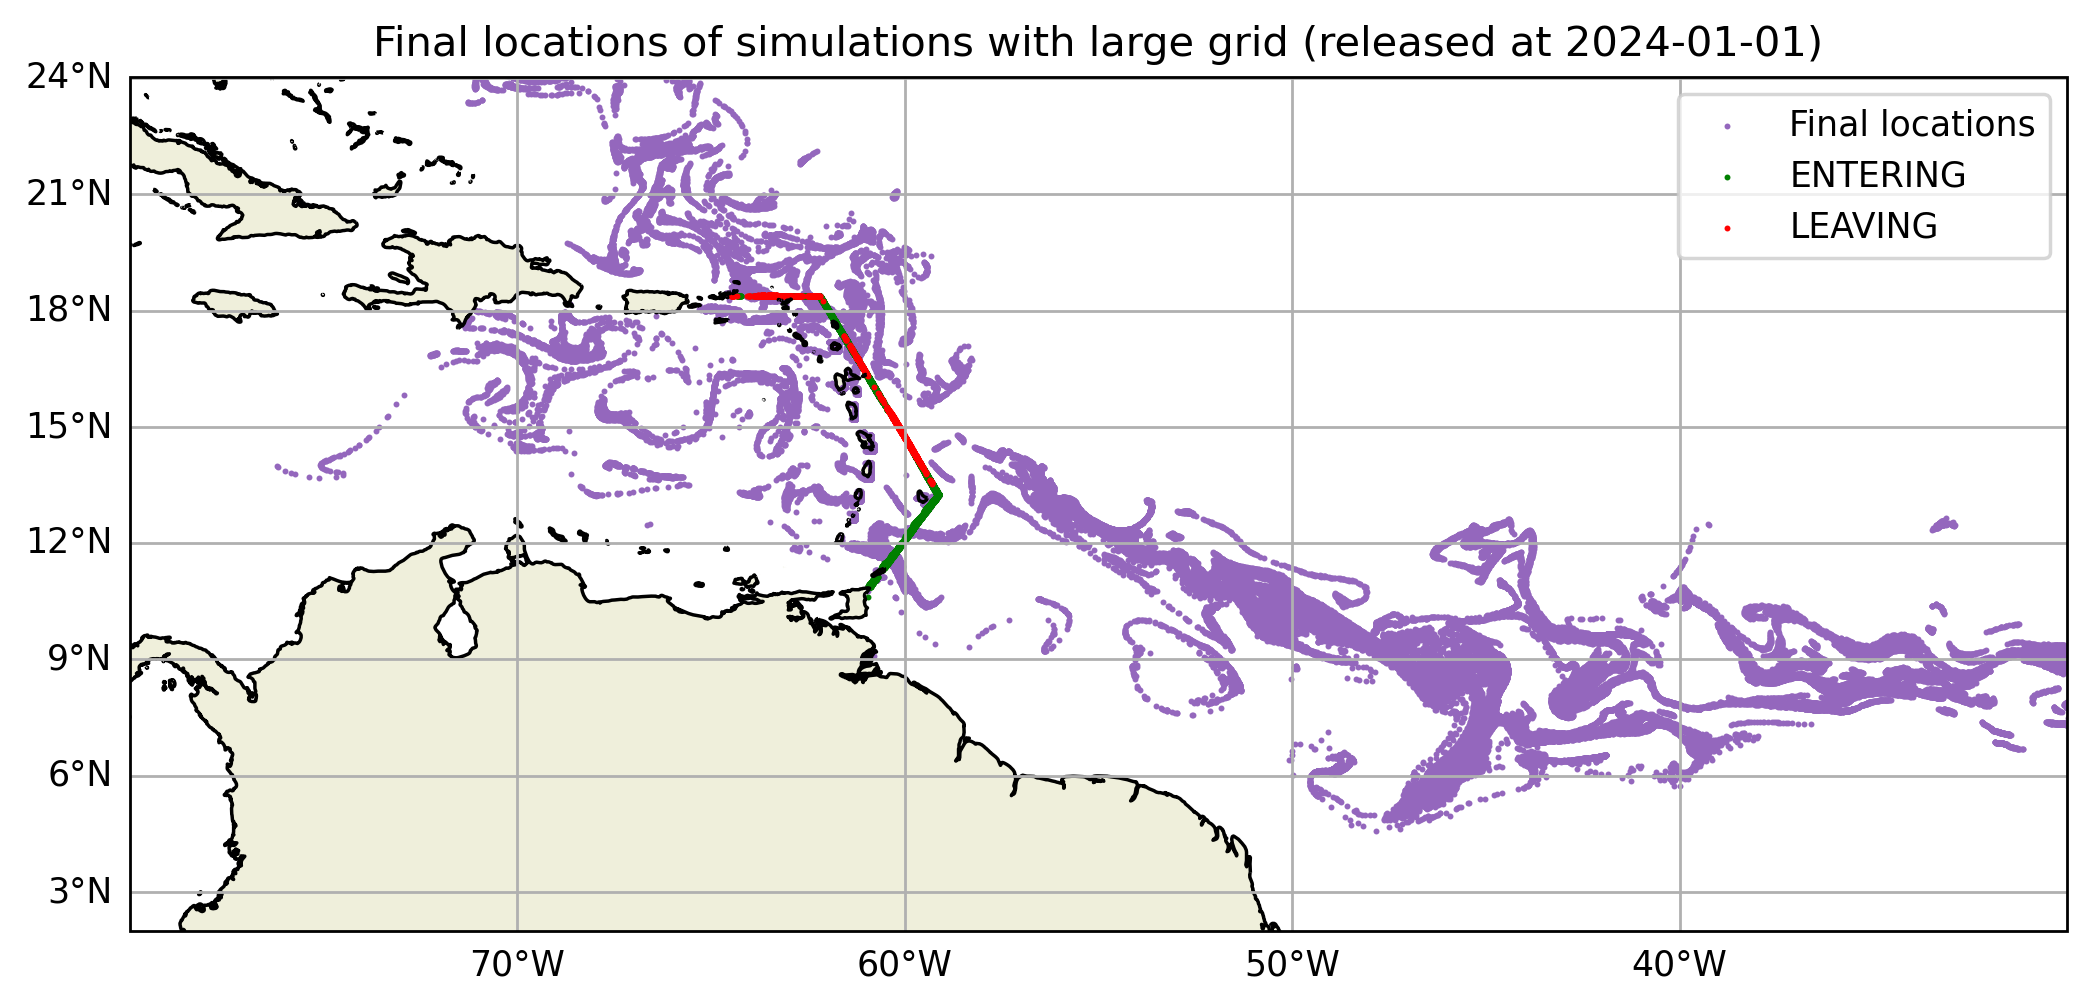

In [ ]:
entering = DSS1.where(first_true_after_false, drop=False)
leaving = DSS1.where(first_false_after_true, drop=False)

#Figure for plotting trajectories
fig2 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
#caribbean_poly.boundary.plot(ax=ax, color='blue')

#End locations scatterplot
#eplot = ax.scatter(DSL1.lon[:,-1], DSL1.lat[:,-1], s = 0.5 ,color='tab:red', label= 'Jan transport') #Transposing lon and lat arrays!
eplot = ax.scatter(DSS1.lon[:,-1], DSS1.lat[:,-1], s = 0.5 ,color='tab:purple', label = 'Final locations') #Transposing lon and lat arrays!

entplot = ax.scatter(entering.lon[:,1:], entering.lat[:,1:], s = 0.5, color= 'green', label='ENTERING')
leavplot = ax.scatter(leaving.lon[:,1:], leaving.lat[:,1:], s = 0.5, color= 'red', label='LEAVING')

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

#gdf.plot(ax=ax, color='lightblue', markersize=20)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Final locations of simulations with large grid (released at {starttimejan.date()})')
ax.set_extent([-80,-30,2,22])
#ax.set_extent([-86,7,-7,19])
ax.legend()
plt.show()

In [ ]:
entering = DSS1.where(first_true_after_false, drop=True)
entering

<xarray.Dataset> Size: 4GB
Dimensions:                 (trajectory: 103642, obs: 372)
Coordinates:
  * obs                     (obs) int32 1kB 0 1 2 3 4 5 ... 367 368 369 370 371
  * trajectory              (trajectory) int64 829kB 0 1 2 ... 103640 103641
Data variables: (12/24)
    biomass_SF3             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    biomass_SN1             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    biomass_SN8             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    biomass_loss            (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    decay_averaged          (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    decay_factor            (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    ...                      ...
    speed_stokes            (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    speed_wind              (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    stranded                (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    temperature             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    time                    (trajectory, obs) datetime64[ns] 308MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    z                       (trajectory, obs) float64 308MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SargassumParticleAdvectionRK4di_Stokes_driftwind_...
    parcels_mesh:           spherical
    parcels_version:        3.1.2

Length:  78205
Frozen({'trajectory': 103642, 'obs': 372})
372
Frozen({'trajectory': 103642, 'obs': 372})
372
(2, 372) (2, 372)
0.027807625089002523
372
372


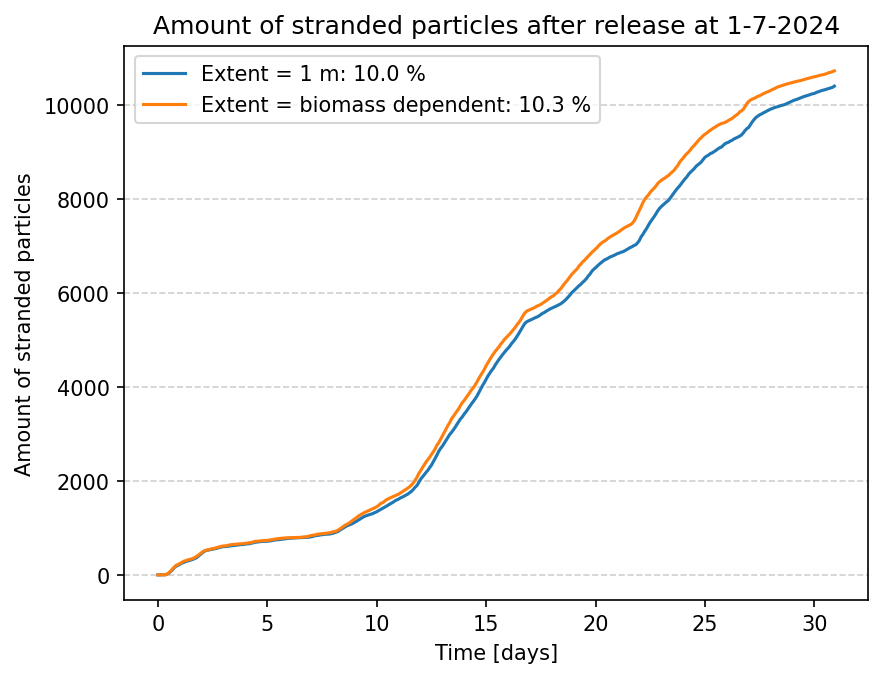

In [15]:
#print(len(DSAAN.trajectory)) ?????????????????????????????????????????????????????????

DSSs = [DSS1, DSS2de]
labels = ['Extent = 1 m', 'Extent = biomass dependent']

strand = []
strand_percentage = []
print('Length: ', len(DSL1.trajectory))
for ds in DSSs:
    # sum stranded particles along the obs dimension (axis=0)
    print(ds.sizes)
    print(len(ds.obs))
    until = len(ds.obs)
    stranded_sum = np.sum(ds.stranded[:,:
    ], axis=0)
    strand.append(stranded_sum)
    stranded_percentage = 100 * stranded_sum / len(ds.trajectory)
    strand_percentage.append(stranded_percentage)

# Convert to a numpy array if needed
strand = np.array(strand)
strand_percentage=np.array(strand_percentage)
print(strand.shape, strand_percentage.shape)
#print(strand_percentage[:,-1])
print(2148/77245)
fig = plt.figure(dpi=150)
for i in range(len(DSSs)):
    until = len(DSSs[i].obs)
    print(until)
    plt.plot(time_in_days[0,:until], strand[i,:until], label = f'{labels[i]}: {strand_percentage[i,-1]:.1f} %')
#lt.plot(time_in_days[0,:], strand)
plt.xlabel('Time [days]')
plt.ylabel('Amount of stranded particles')
plt.legend()
plt.title(f'Amount of stranded particles after release at 1-7-2024')
#plt.title(f'Stranded particels = {(100*strand[-1].values/(len(DSL1.trajectory))):.2f} % of total')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

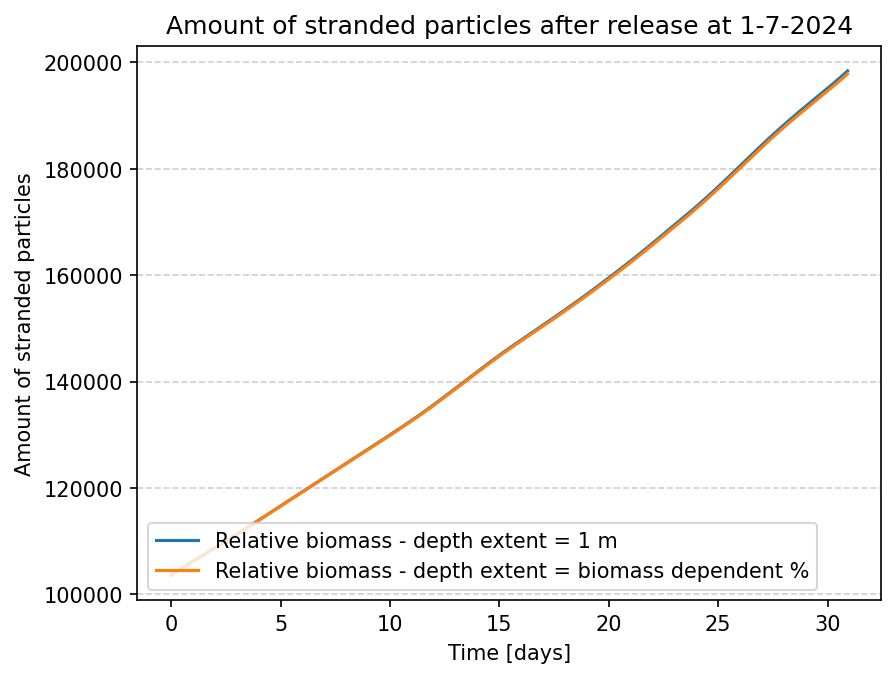

In [16]:
fig = plt.figure(dpi=150)

biomass = [E['biomass_SF3'].sum(dim='trajectory')     for E in DSSs]  

biomass = np.array(biomass)

#biomass_loss = [E['biomass_loss'].sum(dim='trajectory')     for E in DSSs]  
#biomass_loss = np.array(biomass_loss)
plt.plot(time_in_days[0,:], biomass[0,:].T, label = f'Relative biomass - depth extent = 1 m')
plt.plot(time_in_days[0,:], biomass[1,:].T, label = f'Relative biomass - depth extent = biomass dependent %')
#plt.plot(time_in_days[0,:], biomass_loss.T, label = f'Loss  %')
#lt.plot(time_in_days[0,:], strand)
plt.xlabel('Time [days]')
plt.ylabel('Amount of stranded particles')
plt.legend(loc='lower left')
plt.title(f'Amount of stranded particles after release at 1-7-2024')
#plt.title(f'Stranded particels = {(100*strand[-1].values/(len(DSL1.trajectory))):.2f} % of total')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

[-64.37523697 -64.37518641 -64.37513431 ... -13.7664301  -13.76711701
 -13.70547515]
0


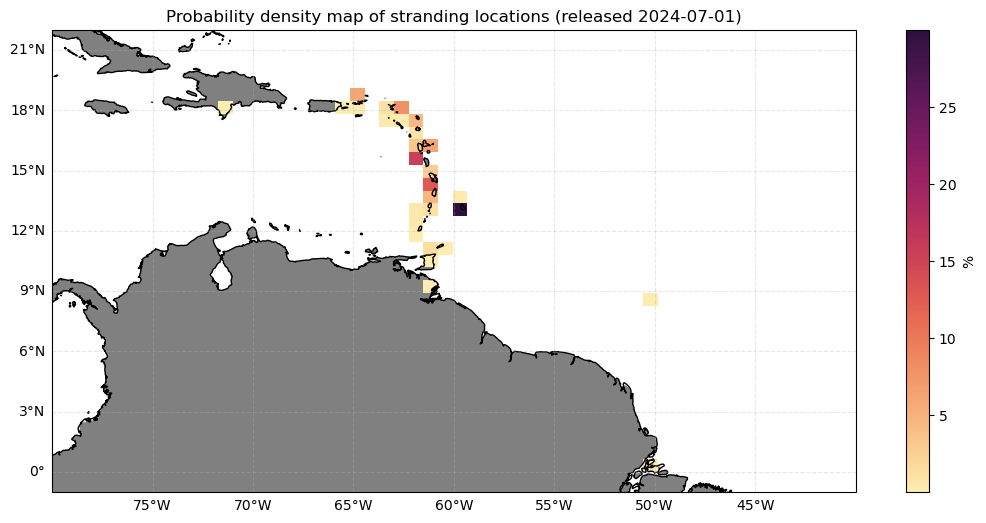

In [17]:
bins_x = 80
bins_y = 30

DSS1_lasttimestep = DSS1.isel(obs=-1)
stranded =  DSS1_lasttimestep.where(DSS1_lasttimestep['stranded'].compute()==1, drop=True)    #for X in DSLs] 

print(stranded.lon.values)
print(np.isnan(stranded.lon.values).sum())  # should be 0 ideally

probability = c_H.probability_density(stranded, bins_x, bins_y)
probability_last = c_H.probability_density(DSS1_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-80, -40]
ylim= [-1, 22]

stranded
#plot the results
c_H.probability_map(probability, xlim, ylim, f'Probability density map of stranding locations (released {starttimejul.date()})', None)

In [18]:
entering = DSS1.where(first_true_after_false, drop=True)
entering_clean = entering.dropna(dim="obs", subset=["lon", "lat"])

bins_x = 20
bins_y = 20

#DSS1_lasttimestep = DSS1.isel(obs=-1)
#stranded =  DSS1_lasttimestep.where(DSS1_lasttimestep['stranded'].compute()==1, drop=True)    #for X in DSLs] 

#print(stranded.lon.values)
#print(np.isnan(stranded.lon.values).sum())  # should be 0 ideally

probability = c_H.probability_density(entering_clean, bins_x, bins_y)
#probability_last = c_H.probability_density(DSS1_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-80, -40]
ylim= [4, 22]

#stranded
#plot the results
c_H.probability_map(probability, xlim, ylim, f'Probability density map of stranding locations (released {starttimejul.date()})', None)

NameError: name 'first_true_after_false' is not defined

In [19]:
def probability_map_12months(DSprobability,  xlim, ylim, title):#FIGURE SETTINGS
    fig, axes = plt.subplots(3,4,     # 3 rows × 4 columns
        figsize=(12,6),
        dpi=240, constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

    #Flattening axes array for loop
    axes = axes.flatten()

    #Plotting for each month
    for i, ax in enumerate(axes):
        ax.set_extent([-72, -14, -5, 19])
        ax.gridlines(draw_labels=False, alpha=0.3, linestyle='--', zorder=1)

        # #Scatter plot for month i
        # cscat = ax.scatter(
        #     DSLs[i].lon[:, -1], #loc
        #     DSLs[i].lat[:, -1], #loc
        #     c=DSLs[i].biomass_SF3[:, -1].values,
        #     cmap=colormap, s=4, linewidth=0, transform=ccrs.PlateCarree(), zorder=2, 
        #     #vmin = 0,  vmax=5 
        #     )

            #create grid
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        

        #gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
        #gl.right_labels = False
        #gl.top_labels = False

        #plotting probability results 
        plot = DSprobability[i].plot(ax=ax, cmap=cmo.matter)
        #Coastlines, land & subfigure title per month i
        ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=3)
        ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2)
        ax.set_title(months[i], fontsize=9)

    #Colorbar and title for all months
    cbar = fig.colorbar(plot, ax=axes, orientation='horizontal', fraction=0.045, pad=0.07, label='Relative biomass difference', extend = 'neither')
    fig.suptitle(title, fontsize = 14)
    return plt.show()

In [21]:
#Calculating mean over time of limitation values 
timemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')     for E in DSSs] 
timemean_lim_temp =   [E['lim_temp'].mean(dim='obs')         for E in DSSs] 
timemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')          for E in DSSs] 
timemean_lim_tot =    [E['limitation'].mean(dim='obs')      for E in DSSs]

Etimemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')    for E in DSSEs] 
Etimemean_lim_temp =   [E['lim_temp'].mean(dim='obs')        for E in DSSEs] 
Etimemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')         for E in DSSEs] 
Etimemean_lim_tot =    [E['limitation'].mean(dim='obs')     for E in DSSEs]


print(np.shape(timemean_lim_no3))
print(type(timemean_lim_sal))

timemean_lim_sal = np.array(timemean_lim_sal)
timemean_lim_temp = np.array(timemean_lim_temp)
timemean_lim_no3 = np.array(timemean_lim_no3)
timemean_lim_tot = np.array(timemean_lim_tot)

Etimemean_lim_sal = np.array(Etimemean_lim_sal)
Etimemean_lim_temp = np.array(Etimemean_lim_temp)
Etimemean_lim_no3 = np.array(Etimemean_lim_no3)
Etimemean_lim_tot = np.array(Etimemean_lim_tot)
#timemean_limE = np.array(timemean_limE)

print(type(timemean_lim_sal))

(2, 103642)
<class 'list'>
<class 'numpy.ndarray'>


In [23]:
#Calculating mean over time of limitation values 
timemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')     for E in DSSs] 
timemean_lim_temp =   [E['lim_temp'].mean(dim='obs')         for E in DSSs] 
timemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')          for E in DSSs] 
timemean_lim_tot =    [E['limitation'].mean(dim='obs')      for E in DSSs]

Etimemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')    for E in DSSEs] 
Etimemean_lim_temp =   [E['lim_temp'].mean(dim='obs')        for E in DSSEs] 
Etimemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')         for E in DSSEs] 
Etimemean_lim_tot =    [E['limitation'].mean(dim='obs')     for E in DSSEs]


print(np.shape(timemean_lim_no3))
print(type(timemean_lim_sal))

timemean_lim_sal = np.array(timemean_lim_sal)
timemean_lim_temp = np.array(timemean_lim_temp)
timemean_lim_no3 = np.array(timemean_lim_no3)
timemean_lim_tot = np.array(timemean_lim_tot)

Etimemean_lim_sal = np.array(Etimemean_lim_sal)
Etimemean_lim_temp = np.array(Etimemean_lim_temp)
Etimemean_lim_no3 = np.array(Etimemean_lim_no3)
Etimemean_lim_tot = np.array(Etimemean_lim_tot)
#timemean_limE = np.array(timemean_limE)

print(type(timemean_lim_sal))

(2, 103642)
<class 'list'>
<class 'numpy.ndarray'>


(2, 103642)
<class 'list'>
<class 'list'> (4, 103642)


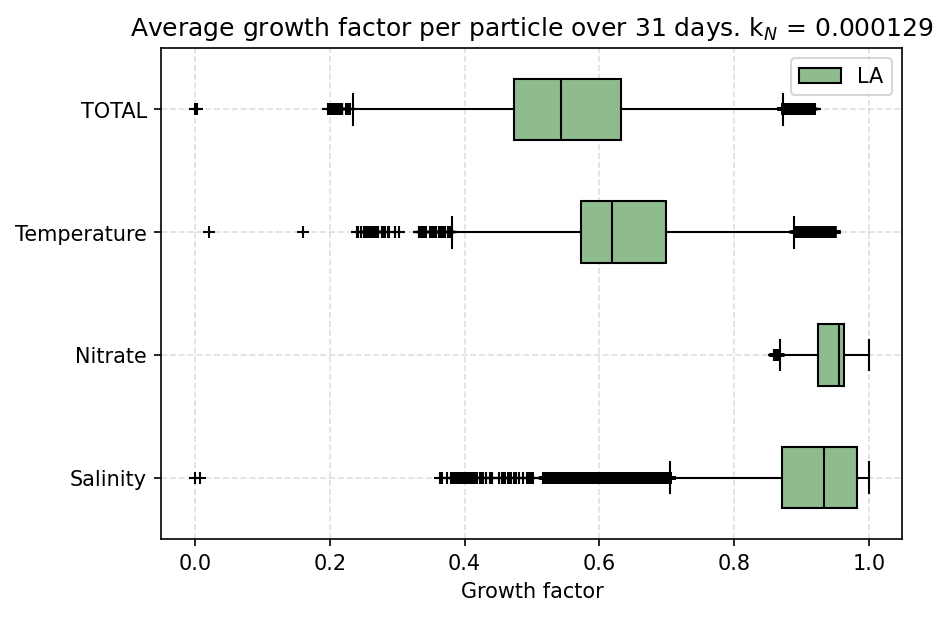

In [24]:
#Calculating mean over time of limitation values 
timemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')     for E in DSSs] 
timemean_lim_temp =   [E['lim_temp'].mean(dim='obs')         for E in DSSs] 
timemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')          for E in DSSs] 
timemean_lim_tot =    [E['limitation'].mean(dim='obs')      for E in DSSs]



print(np.shape(timemean_lim_no3))
print(type(timemean_lim_sal))

timemean_lim_sal = np.array(timemean_lim_sal)
timemean_lim_temp = np.array(timemean_lim_temp)
timemean_lim_no3 = np.array(timemean_lim_no3)
timemean_lim_tot = np.array(timemean_lim_tot)


boxplot_list_DSL_lim = [timemean_lim_sal[0,:], timemean_lim_no3[0,:], timemean_lim_temp[0,:], timemean_lim_tot[0,:]] 
#boxplot_list_DSE_lim = [Etimemean_lim_sal[0,:], Etimemean_lim_no3[0,:], Etimemean_lim_temp[0,:], Etimemean_lim_tot[0,:]] 
print(type(boxplot_list_DSL_lim), np.shape(boxplot_list_DSL_lim))
limitation_names = ['Salinity', 'Nitrate', 'Temperature', 'TOTAL']

# X positions for each month
positions_DSE = np.arange(len(limitation_names)) * 1  # spacing between month groups
positions_DSL = positions_DSE          # offset for second box (DSE)

# Create plot
plt.figure(figsize=(6,4), constrained_layout=True, dpi=150)

# Boxplots for both groups
# plt.boxplot(boxplot_list_DSE_lim, orientation= 'horizontal' ,positions=positions_DSE, widths=0.5, label='EU', patch_artist=True,
#             boxprops=dict(facecolor='peachpuff'), medianprops=dict(color='black'), sym='+')
plt.boxplot(boxplot_list_DSL_lim, orientation= 'horizontal', positions=positions_DSL, widths=0.5, label='LA', patch_artist=True,
            boxprops=dict(facecolor='darkseagreen'), medianprops=dict(color='black'), sym='+')

# Labels & legend
plt.yticks(positions_DSL , limitation_names, rotation=0)
plt.xlabel('Growth factor')
#plt.ylabel('Average limitation factor (-)')
plt.title(f'Average growth factor per particle over 31 days. k$_N$ = 0.000129')
plt.legend( loc='upper right')
#plt.ylim(-0.05,1.05)
plt.grid( linestyle='--', alpha=0.4)
plt.show()

<class 'list'> (4, 103642)


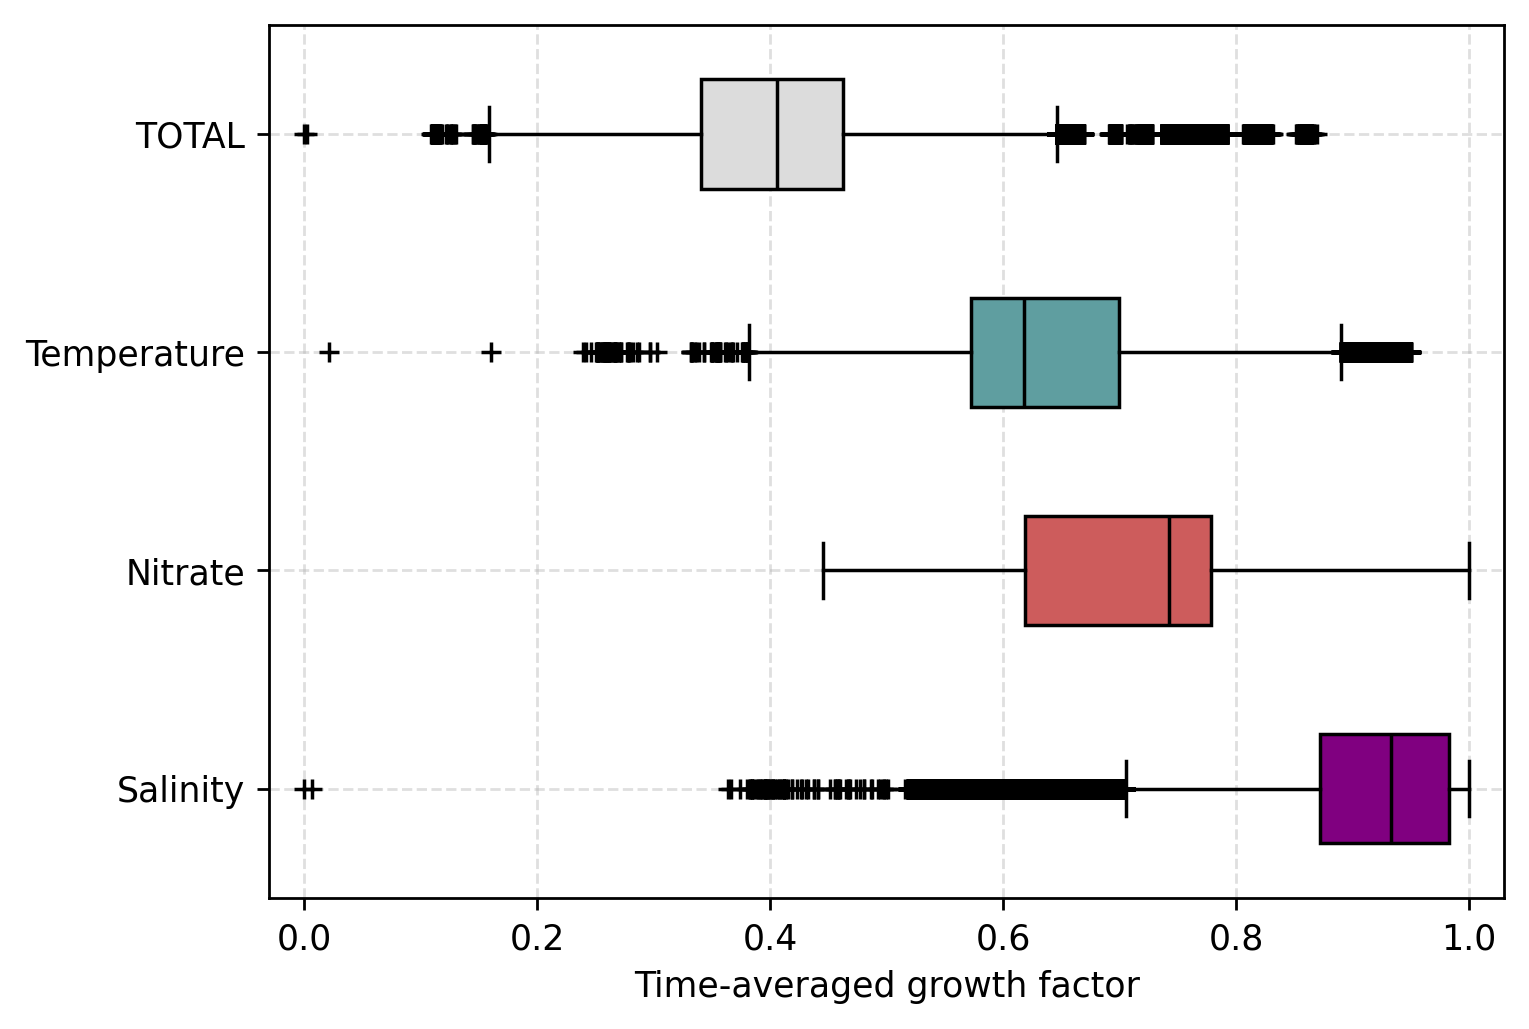

In [25]:
DSNs = [DSSN2] #Second simulation!!!

#Calculating mean over time of limitation values 
timemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')     for E in DSNs] 
timemean_lim_temp =   [E['lim_temp'].mean(dim='obs')         for E in DSNs] 
timemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')          for E in DSNs] 
timemean_lim_tot =    [E['limitation'].mean(dim='obs')      for E in DSNs]

timemean_lim_sal = np.array(timemean_lim_sal)
timemean_lim_temp = np.array(timemean_lim_temp)
timemean_lim_no3 = np.array(timemean_lim_no3)
timemean_lim_tot = np.array(timemean_lim_tot)

boxplot_list = [timemean_lim_sal[0,:], timemean_lim_no3[0,:], timemean_lim_temp[0,:], timemean_lim_tot[0,:]] 
print(type(boxplot_list), np.shape(boxplot_list))
      
limitation_names = ['Salinity', 'Nitrate', 'Temperature', '''TOTAL''']
colors = ['purple' , 'indianred', 'cadetblue', 'gainsboro']

#Positions for each month
positions = np.arange(len(limitation_names)) 

plt.figure(figsize=(6,4), constrained_layout=True, dpi=250)

#Boxplots with different colors
for i, data in enumerate(boxplot_list):
    plt.boxplot(
        data,
        positions=[positions[i]],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i]),
        medianprops=dict(color='black'),
        sym='+'
    )

plt.yticks(positions , limitation_names, rotation=0)
plt.xlabel('Time-averaged growth factor')
#plt.title(f'Time-averaged growth factors per trajectory')
plt.xlim(-0.03,1.03)
plt.grid( linestyle='--', alpha=0.4)
plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/growth_factor_all.pdf", format="pdf", bbox_inches="tight")
plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/growth_factor_all.png", format="png", bbox_inches="tight")
plt.show()

(1, 103642)
<class 'list'>
<class 'numpy.ndarray'>
<class 'list'> (4, 103642)


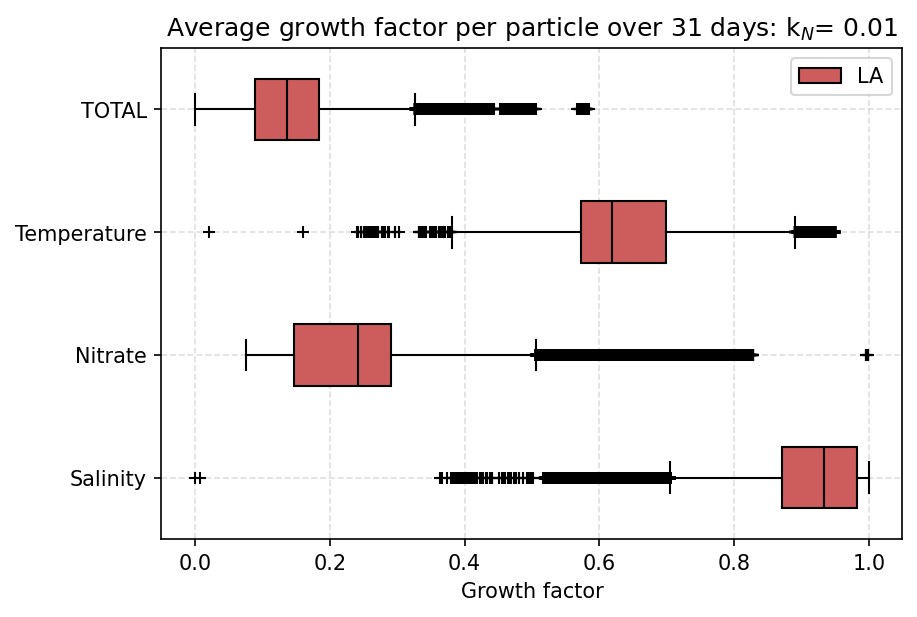

In [9]:
DSN = [DSSN3]
#Calculating mean over time of limitation values 
timemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')     for E in DSN] 
timemean_lim_temp =   [E['lim_temp'].mean(dim='obs')         for E in DSN] 
timemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')          for E in DSN] 
timemean_lim_tot =    [E['limitation'].mean(dim='obs')      for E in DSN]


print(np.shape(timemean_lim_no3))
print(type(timemean_lim_sal))

timemean_lim_sal = np.array(timemean_lim_sal)
timemean_lim_temp = np.array(timemean_lim_temp)
timemean_lim_no3 = np.array(timemean_lim_no3)
timemean_lim_tot = np.array(timemean_lim_tot)

print(type(timemean_lim_sal))

boxplot_list_DSL_lim = [timemean_lim_sal[0,:], timemean_lim_no3[0,:], timemean_lim_temp[0,:], timemean_lim_tot[0,:]] 
#boxplot_list_DSE_lim = [Etimemean_lim_sal[0,:], Etimemean_lim_no3[0,:], Etimemean_lim_temp[0,:], Etimemean_lim_tot[0,:]] 
print(type(boxplot_list_DSL_lim), np.shape(boxplot_list_DSL_lim))
limitation_names = ['Salinity', 'Nitrate', 'Temperature', 'TOTAL']
colors = ['white', 'cadetblue', 'indianred', 'indigo']

# X positions for each month
positions_DSE = np.arange(len(limitation_names)) * 1  # spacing between month groups
positions_DSL = positions_DSE          # offset for second box (DSE)

# Create plot
plt.figure(figsize=(6,4), constrained_layout=True, dpi=150)

# Boxplots for both groups
# plt.boxplot(boxplot_list_DSE_lim, orientation= 'horizontal' ,positions=positions_DSE, widths=0.5, label='EU', patch_artist=True,
#             boxprops=dict(facecolor='peachpuff'), medianprops=dict(color='black'), sym='+')
plt.boxplot(boxplot_list_DSL_lim, orientation= 'horizontal', positions=positions_DSL, widths=0.5, label='LA', patch_artist=True,
            boxprops=dict(facecolor=colors[i]), medianprops=dict(color='black'), sym='+')

# Labels & legend
plt.yticks(positions_DSL , limitation_names, rotation=0)
plt.xlabel('Growth factor')
#plt.ylabel('Average limitation factor (-)')
plt.title(f'Average growth factor per particle over 31 days: k$_N$= 0.01')
plt.legend( loc='upper right')
#plt.ylim(-0.05,1.05)
plt.grid( linestyle='--', alpha=0.4)
plt.show()

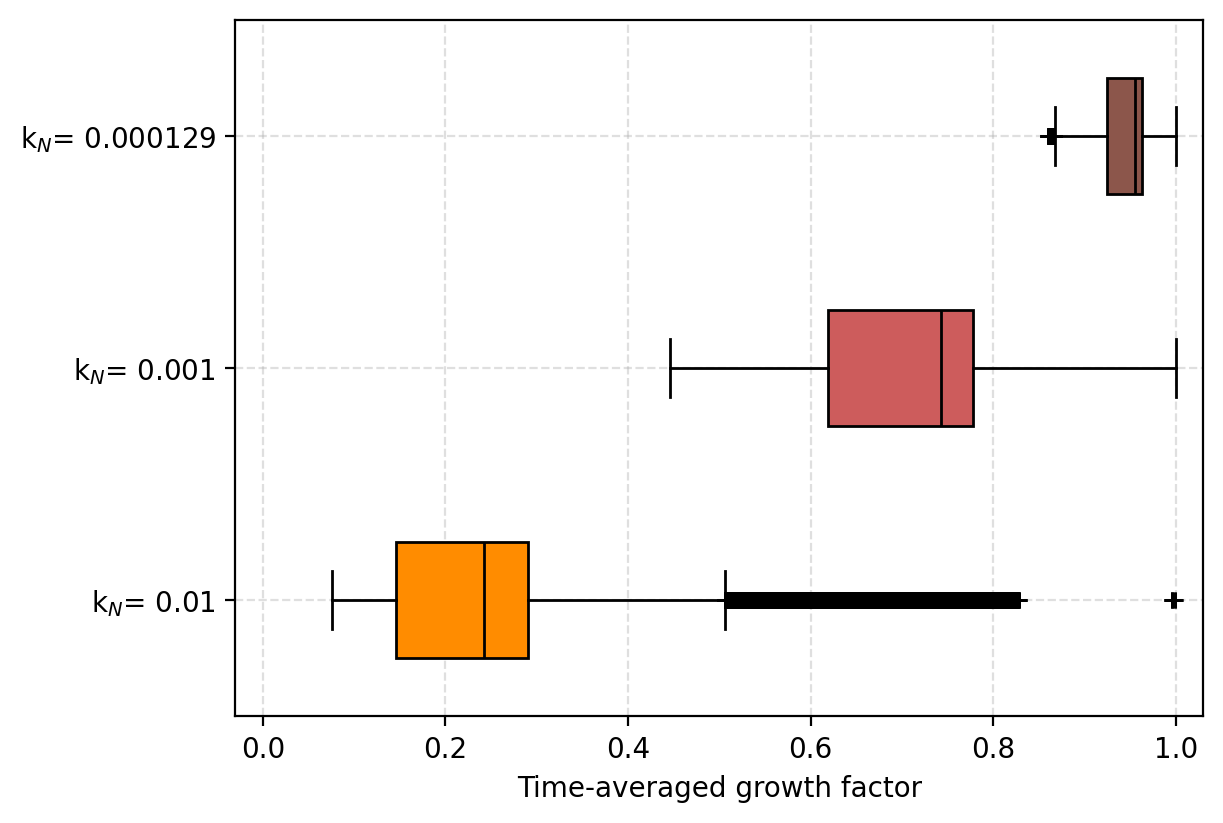

In [22]:
#Datasets nitrate
DSN = [DSSN3, DSSN2, DSS1]

#Calculate time-mean limitation values
timemean_lim_no3 = np.array([E['lim_no3'].mean(dim='obs') for E in DSN])

#Selecting timemeans of all no3 data of three simulations
boxplot_list = [timemean_lim_no3[i, :] for i in range(3)]

#Positions, colors, names
positions = np.arange(len(boxplot_list))
colors = ['darkorange', 'indianred', 'tab:brown']
names = [f'k$_N$= 0.01', f'k$_N$= 0.001', f'k$_N$= 0.000129']

# Plot
plt.figure(figsize=(6, 4), constrained_layout=True, dpi=200)

for i, data in enumerate(boxplot_list):
    plt.boxplot(
        data,
        positions=[positions[i]],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i]),
        medianprops=dict(color='black'),
        sym='+'
    )

#Assiging labels
for i, name in enumerate(names):
    plt.plot([], [], color=colors[i], label=name) 

plt.yticks(positions, names)
plt.xlabel('Time-averaged growth factor')
#plt.title('Time-averaged NO$_3$ growth factor per trajectory')
plt.xlim(-0.03,1.03)
plt.grid(linestyle='--', alpha=0.4)
plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/growth_factor_kN.pdf", format="pdf", bbox_inches="tight")
plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/growth_factor_kN.png", format="png", bbox_inches="tight")
plt.show()


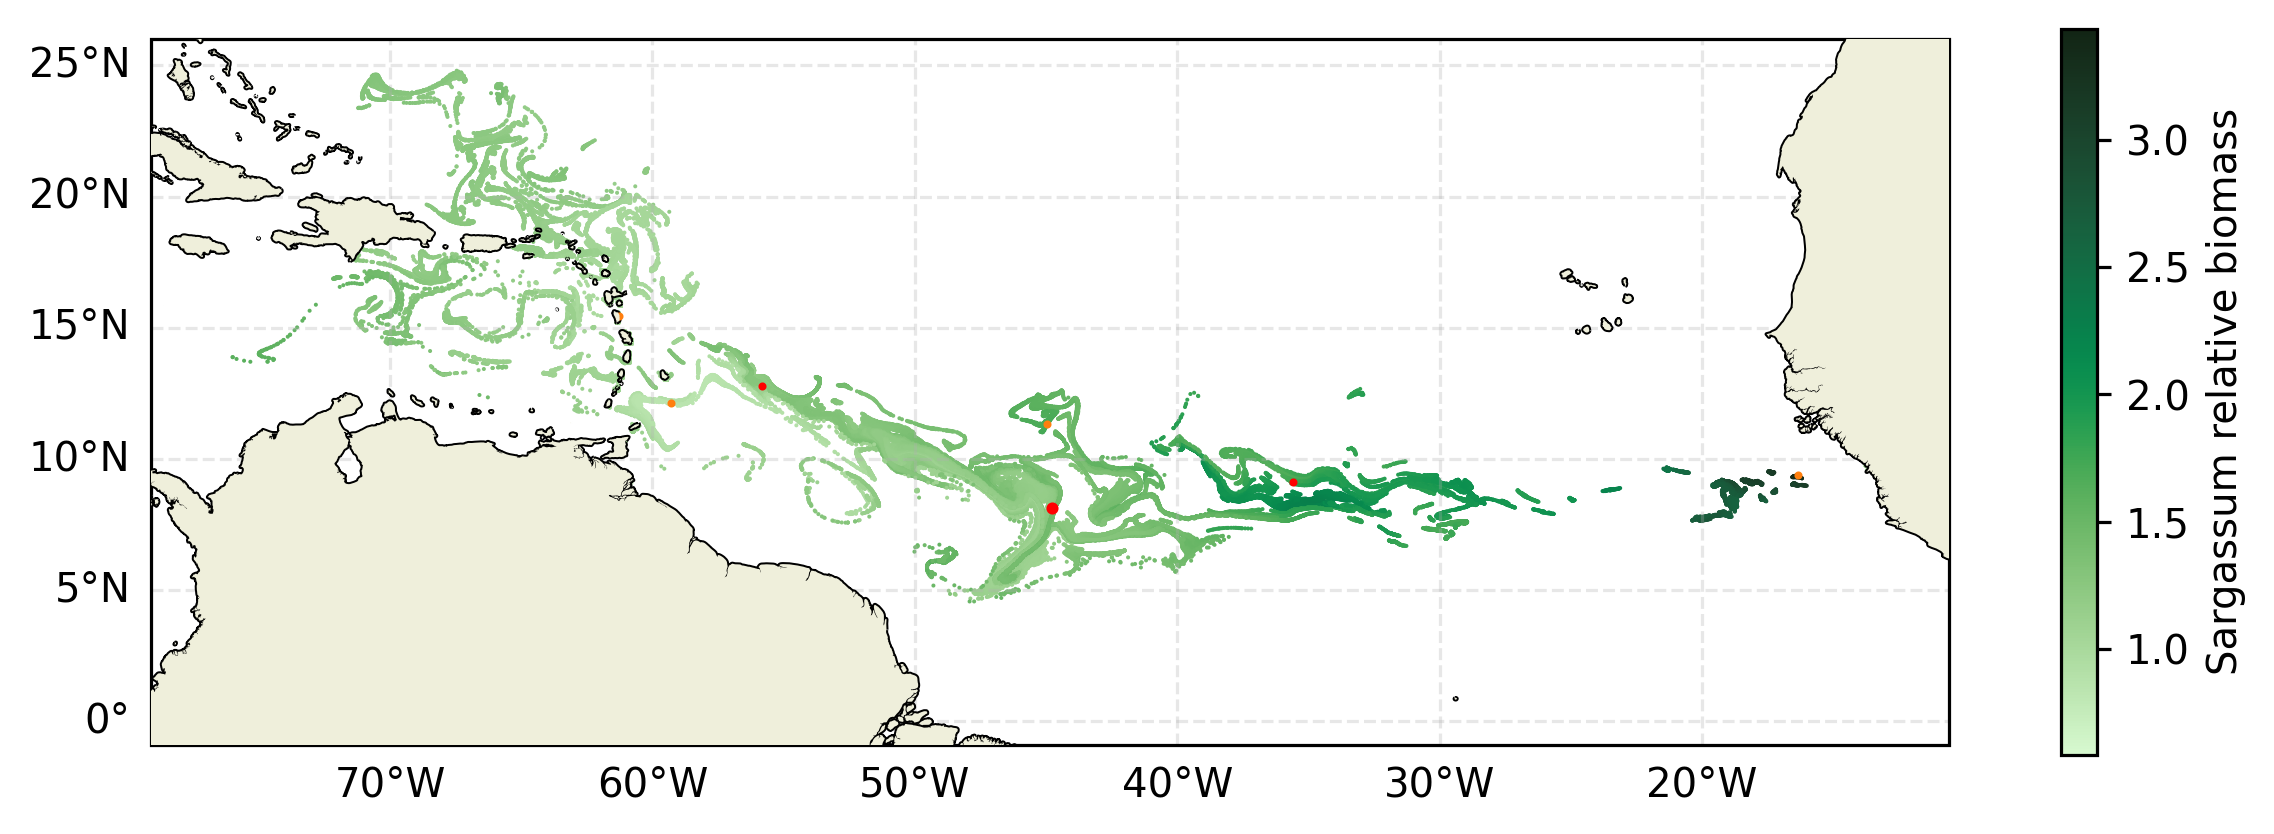

In [80]:
def biomass_plot(DATA, COLORMAP, STARTTIME, FINAL=True):

    colormap = COLORMAP

    #FIGURE
    fig = plt.figure(figsize = (10,5), dpi=290)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

    ax.scatter(DATA.lon[86483,-1], DATA.lat[86483,-1], s=1, transform=ccrs.PlateCarree(), zorder=3, c = 'tab:orange')
    ax.scatter(DATA.lon[31000,-1], DATA.lat[31000,-1], s=1, transform=ccrs.PlateCarree(), zorder=3, c = 'red')
    ax.scatter(DATA.lon[14910,-1], DATA.lat[14910,-1], s=1, transform=ccrs.PlateCarree(), zorder=3, c = 'tab:orange')
    ax.scatter(DATA.lon[50000,-1], DATA.lat[50000,-1], s=4, transform=ccrs.PlateCarree(), zorder=3, c = 'red')
    ax.scatter(DATA.lon[29000,-1], DATA.lat[29000,-1], s=1, transform=ccrs.PlateCarree(), zorder=3, c = 'tab:orange')
    ax.scatter(DATA.lon[97000,-1], DATA.lat[97000,-1], s=1, transform=ccrs.PlateCarree(), zorder=3, c = 'red')
    ax.scatter(DATA.lon[96922,-1], DATA.lat[96922,-1], s=1, transform=ccrs.PlateCarree(), zorder=3, c = 'tab:orange')

    if FINAL == True:
        cscat = ax.scatter(DATA.lon[:,-1], DATA.lat[:,-1], c = DATA.biomass_SF3[:,-1].values,
        cmap=colormap, s=1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)
    else:
    #Colored scatter plot with STARTING lon, lat and FINAL values of the categorized weight
        cscat = ax.scatter(DATA.lon[:,0], DATA.lat[:,0], c = DATA.biomass_SF3[:,-1].values,
        cmap=colormap, s=2, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)

    #Other figure settings
    ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
    ax.add_feature(cartopy.feature.LAND.with_scale('10m'),zorder=3)
    #if FINAL == True:
        #ax.set_title(f'Relative biomass after 31 days (released {STARTTIME.date()})')
    #else:
       # ax.set_title(f'Potential biomass after 31 days, plotted at initial location (released {STARTTIME.date()})')

    #ax.set_extent([-59,-50,3,12])
    cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Sargassum relative biomass', shrink=0.65)
    plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/biomass.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/biomass.png", format="png", bbox_inches="tight")
    return plt.show()

biomass_plot(DSSN2, cmo.algae, starttimejul, FINAL=True)

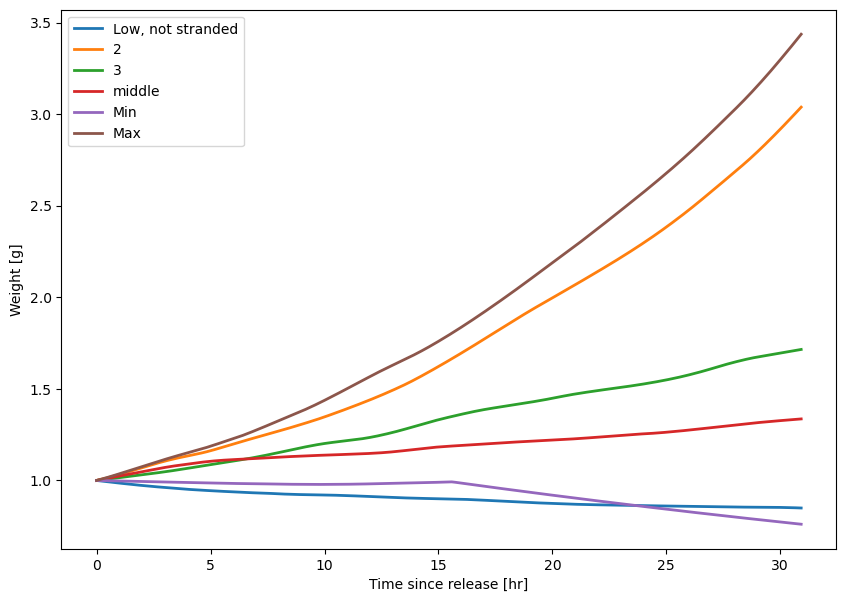

In [84]:
figweight = plt.figure(figsize = (10,7))
plt.plot(time_in_days[86483,:].transpose(), DSSN2.biomass_SF3[86483,:].transpose(), linewidth=2 , label='Low, not stranded')
plt.plot(time_in_days[99910,:].transpose(), DSSN2.biomass_SF3[99910,:].transpose(), linewidth=2 , label='2')
plt.plot(time_in_days[29000,:].transpose(), DSSN2.biomass_SF3[29000,:].transpose(), linewidth=2 , label='3')
plt.plot(time_in_days[50000,:].transpose(), DSSN2.biomass_SF3[50000,:].transpose(), linewidth=2 , label='middle')
plt.plot(time_in_days[14910,:].transpose(), DSSN2.biomass_SF3[14910,:].transpose(), linewidth=2 , label='Min')
plt.plot(time_in_days[96922,:].transpose(), DSSN2.biomass_SF3[96922,:].transpose(), linewidth=2 , label='Max')
#plt.plot(time_in_hours.transpose(), DS.weight_SN8.transpose() )
#plt.title(f'Parcel weight over time (released at {starttime.date()})')
plt.xlabel('Time since release [hr]')
plt.ylabel('Weight [g]')
plt.legend()
plt.show()

In [82]:
idmax = np.where(DSSN2.biomass_SF3[:, -1] > 3)[0]
print(idmax)

idmin = np.where(DSSN2.biomass_SF3[:, -1] < 1 )[0]
print(idmin)

idx = np.where((DSSN2.biomass_SF3[:, -1] < 0.85) & 
                 (DSSN2.stranded[:, -1] != 1))[0]
print(idx)

[ 96922  96923  96924  96925  96926  96927  96928  96929  96930  96931
  96932  96981  96982  96983  96984  96985  96986  96987  96988  96989
  96990  96991  97040  97041  97042  97043  97044  97045  97046  97047
  97048  97049  97050  97099  97100  97101  97102  97103  97104  97105
  97106  97107  97108  97109  97158  97159  97160  97161  97162  97163
  97164  97165  97166  97167  97168  98371  98372  98373  98374  98375
  98437  98438  98439  98440  98441  98503  98504  98505  98506  98507
  98569  98570  98571  98572  98573  98635  98636  98637  98638  98639
  98701  98702  98703  98704  98705  98773  98774  98775  98776  98777
  98778  98779  98780  98781  98782  98783  98851  98852  98853  98854
  98855  98856  98857  98858  98859  98860  98861  98929  98930  98931
  98932  98933  98934  98935  98936  98937  98938  98939  99007  99008
  99009  99010  99011  99012  99013  99014  99015  99016  99017  99085
  99086  99087  99088  99089  99090  99091  99092  99093  99094  99095
  9915

In [ ]:
bins_x = 55
bins_y = 25

not_stranded =  DSS1.where(DSS1['stranded'].compute()==0, drop=True)    #for X in DSLs] 

print(not_stranded.sizes)

print(not_stranded.lon.values)
print(np.isnan(not_stranded.lon.values).sum())  # should be 0 ideally

DSS1_lasttimestep = not_stranded.isel(obs=-1)

probability = c_H.probability_density(not_stranded, bins_x, bins_y)
probability_last = c_H.probability_density(DSS1_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-85, -20]
ylim= [-5, 27]

#plot the results
c_H.probability_map(probability, xlim, ylim, f'Probability density map (released {starttimejul.date()})', None)

Frozen({'trajectory': 103642, 'obs': 372})
[[-61.23572208 -61.24375962 -61.2512423  ... -64.83801887 -64.84964543
  -64.8601639 ]
 [-61.21753365 -61.22549953 -61.23295806 ... -64.72511452 -64.7343626
  -64.74409022]
 [-61.19934522 -61.20725232 -61.2146903  ... -64.67130056 -64.68068624
  -64.68983925]
 ...
 [-28.86959506 -28.81809614 -28.76479464 ... -20.37711247 -20.3542022
  -20.3317601 ]
 [-28.851407   -28.79958202 -28.74600819 ... -20.36618284 -20.34324701
  -20.32079501]
 [-28.83321894 -28.7810716  -28.7272051  ... -20.35794771 -20.33500815
  -20.31257783]]
1727230


ValueError: autodetected range of [nan, nan] is not finite

Total value:  100.0


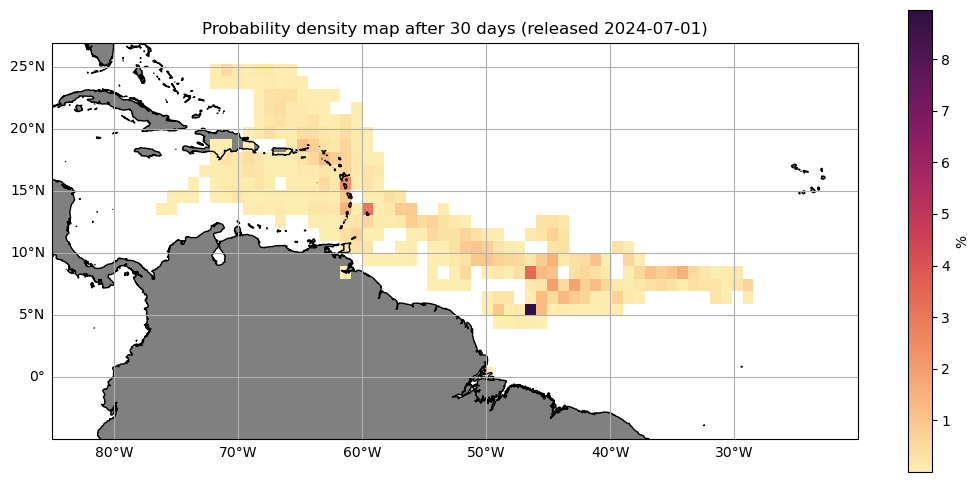

In [ ]:
print('Total value: ', np.nansum(probability_last.values))

c_H.probability_map(probability_last, xlim, ylim, f'Probability density map after 30 days (released {starttimejul.date()})', None)

(1,) (1,) (1,)
<class 'list'>


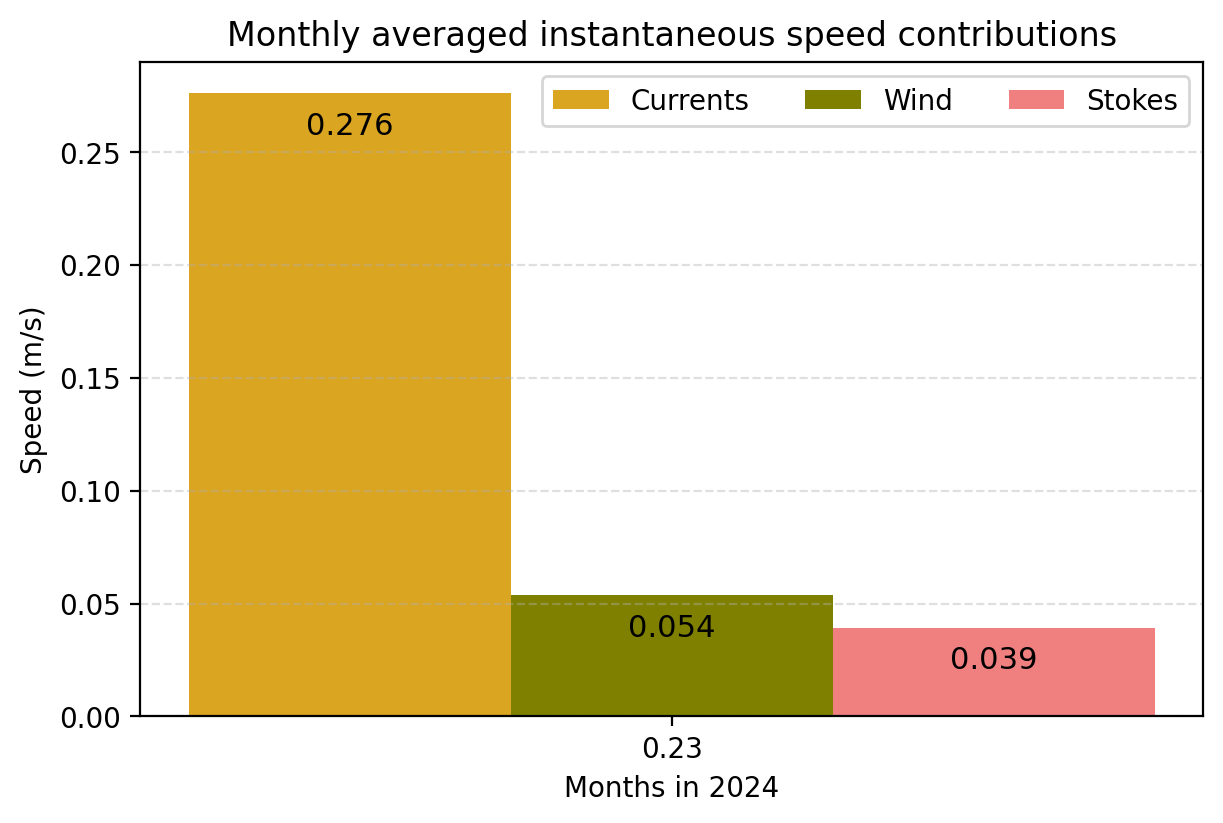

In [ ]:
#ANALYZING THE DIFFERENT CONTRIBUTIONS OF CURRENTS, STOKES AND WIND ON THE PARTICLES

#Preparing
Data = [DSSN2]
#Multiplying surface stokes drift with local decay factor
for X in Data:
     X["speed_stokes_decay"] = X['speed_stokes'] * X['decay_factor']

#print(DSL1.speed_currents.dims)

#Calculating mean of whole dataset 
mean_currents =     [X['speed_currents'].mean()    for X in Data] 
mean_stokes =       [X['speed_stokes_decay'].mean()    for X in Data] 
mean_wind =         [(X['speed_wind']*X['wind_coefficient']).mean()        for X in Data] 



print(np.shape(mean_currents), np.shape(mean_stokes), np.shape(mean_wind))
print(type(mean_currents))


#Defining MEAN velocities as dictionary
speed_means = {'Currents': mean_currents, 
             'Wind': mean_wind, 
             'Stokes': mean_stokes}


#Bar chart settings
x = np.arange(len(mean_currents))  # the label locations
width = 0.23  # the width of the bars
multiplier = 0
colors=['goldenrod', 'olive', 'lightcoral']

#FIGURE GROUPED BAR CHART
fig, ax = plt.subplots(figsize = (6,4),layout='constrained',dpi = 200)

#Looping over dictionary of means
for (attribute, measurement), c in zip(speed_means.items(), colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=c)
    ax.bar_label(rects, padding=-17, fontsize=11, fmt='%.3f')
    multiplier += 1

#Figure settings
ax.set_ylabel('Speed (m/s)')

ax.set_xticks(x + width)
#ax.set_xticklabels(months, rotation=20)
ax.set_xlabel('Months in 2024')
ax.grid(axis='y', linestyle='--', alpha=0.4)
#ax.set_ylim(0,1)
ax.legend(  loc='upper right', ncols=3)
plt.show()

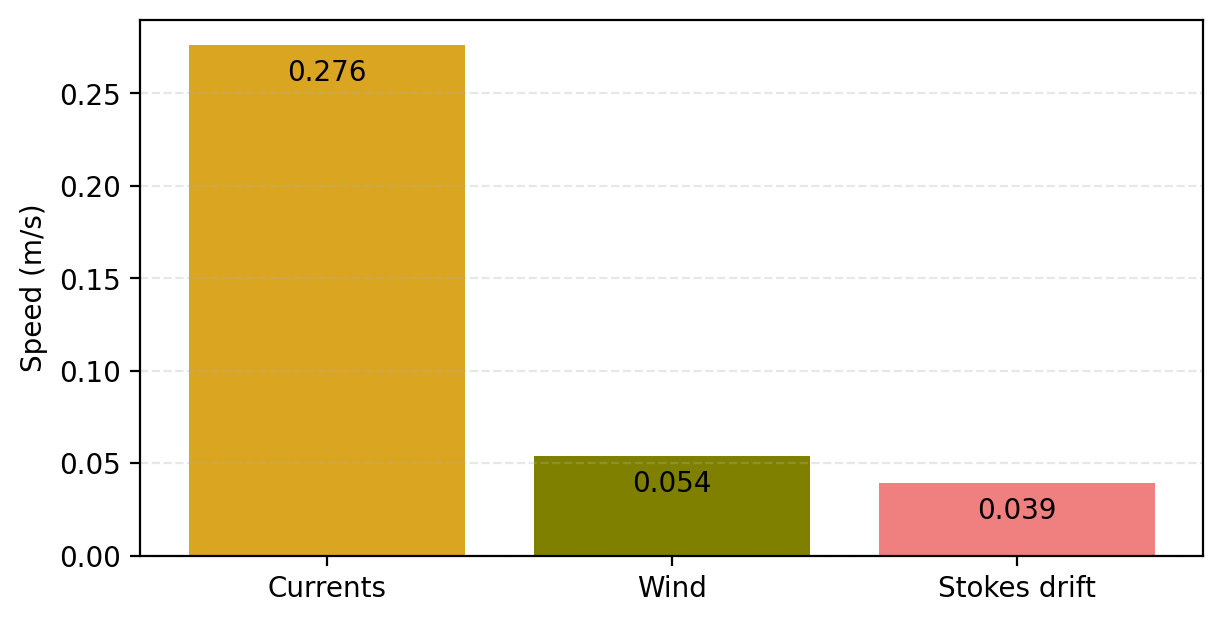

In [35]:
mean_currents_val = np.mean(mean_currents)
mean_wind_val     = np.mean(mean_wind)
mean_stokes_val   = np.mean(mean_stokes)

speed_means = {
    'Currents': mean_currents_val,
    'Wind': mean_wind_val,
    'Stokes drift': mean_stokes_val
}

labels = list(speed_means.keys())
values = list(speed_means.values())
colors = ['goldenrod', 'olive', 'lightcoral']

fig, ax = plt.subplots(figsize=(6,3), layout='constrained', dpi=200)

x = np.arange(len(labels))
bars = ax.bar(x, values, color=colors,zorder=1)

ax.bar_label(bars, padding=-15, fontsize=10, fmt='%.3f')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Speed (m/s)')
#ax.set_title('Mean instantaneous speed contributions')
ax.grid(axis='y', linestyle='--', alpha=0.3,zorder=0)
plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/speed_cont.pdf", format="pdf", bbox_inches="tight")
plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/speed_cont.png", format="png", bbox_inches="tight")
plt.show()

In [ ]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation, FFMpegWriter

fig = plt.figure(figsize = (9,5), constrained_layout=True, dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_extent([-90,10,-8,20])

# show only every 5th output (for speed in creating the animation)
timerange = np.unique(DSS1["time"].values)[::2]


# Indices of the data where time = 0
time_id = np.where(DSS1["time"] == timerange[0])

cscat = ax.scatter(
    DSS1.lon.values[time_id],
    DSS1.lat.values[time_id],
    c=(DSS1.biomass_SF3_categorized.values[time_id].flatten()) - 1,
    cmap=colormap,
    norm=norm,
    s=20,
    linewidth=0,
    transform=ccrs.PlateCarree()
)

t = str(timerange[0].astype("timedelta64[h]")) 
title = ax.set_title(f"Particles at t = {(t)}")
print(t)

def animate(i):
    t = (timerange[i] - timerange[0]).astype('timedelta64[s]').astype(float) / ( 24 * 60 * 60)
    title.set_text(f"Particles at t = {t:.1f} days")

    time_id = np.where(DSS1["time"] == timerange[i])
    cscat.set_offsets(np.c_[DSS1["lon"].values[time_id], DSS1["lat"].values[time_id]])
    cscat.set_array((DSS1.biomass_SF3_categorized.values[time_id].flatten()) - 1)


anim = FuncAnimation(fig, animate, frames=len(timerange), interval=20)

writervideo = FFMpegWriter(fps=40)
anim.save('Anim_sat_colored.mp4', writer=writervideo)
plt.close()